# Week 04 · Image Enhancement — Spatial Filtering
**Course:** Computer Vision (BCSE2022)
**Instructor:** Bùi Huy Kiên
**Prepared:** 2025-10-17


## 🎯 Mục tiêu học tập
Sau khi hoàn thành bài học này, sinh viên sẽ có thể:
- Nắm khái niệm và phân loại phép toán miền không gian (spatial domain operations).
- Phân biệt và vận dụng tích chập vs tương quan; hiểu ý nghĩa "lật kernel".
- Áp dụng bộ lọc tuyến tính làm mịn (box, Gaussian) và đánh giá ảnh hưởng tới nhiễu/biên.
- Áp dụng bộ lọc trung vị để khử nhiễu muối–tiêu, so sánh với lọc tuyến tính.
- Sử dụng Laplacian / Unsharp để làm sắc nét và phát hiện chi tiết.
- Thực hành cài đặt các bộ lọc bằng Python/OpenCV, lựa chọn padding phù hợp và so sánh kết quả.


**Hướng dẫn:**
- Đặt các ảnh input theo tên ghi trong từng cell hoặc sửa đường dẫn cho phù hợp.
- Mỗi cell hiển thị ảnh dùng `matplotlib`.
- Sử dụng các thư viện: `opencv-python`, `numpy`, `matplotlib`.
- Nếu được, khuyến khích xây dựng lại các thuật toán sử dụng C++/Python


Ảnh f (impulse):
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]] 

Kernel w:
 [[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]] 

Correlation f ∘ w (kernel bị 'in ngược' quanh impulse):
 [[0. 0. 0. 0. 0.]
 [0. 9. 8. 7. 0.]
 [0. 6. 5. 4. 0.]
 [0. 3. 2. 1. 0.]
 [0. 0. 0. 0. 0.]] 

Convolution f * w (kernel được 'in đúng chiều'):
 [[0. 0. 0. 0. 0.]
 [0. 1. 2. 3. 0.]
 [0. 4. 5. 6. 0.]
 [0. 7. 8. 9. 0.]
 [0. 0. 0. 0. 0.]]


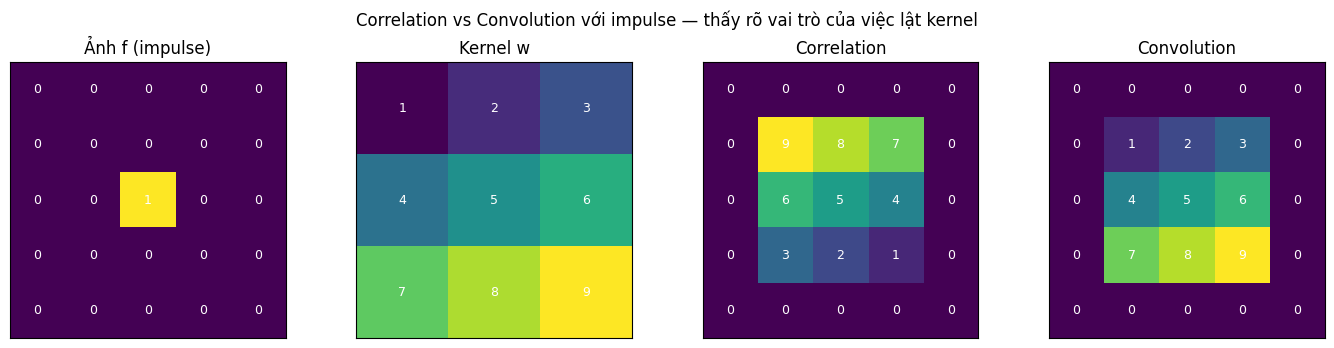

In [1]:
## Ví dụ 1: Tương quan (Correlation) vs Tích chập (Convolution)
# Minh họa trên ma trận nhỏ với kernel BẤT ĐỐI XỨNG để thấy rõ sự khác biệt:
# - Correlation: trượt kernel trực tiếp trên ảnh.
# - Convolution: LẬT kernel 180 độ trước khi trượt.

import numpy as np
import cv2
import matplotlib.pyplot as plt

# Ảnh nhỏ 5x5: một xung đơn vị (impulse) ở giữa
f = np.zeros((5, 5), dtype=np.float32)
f[2, 2] = 1.0

# Kernel bất đối xứng 3x3
w = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype=np.float32)

# cv2.filter2D thực hiện CORRELATION
corr = cv2.filter2D(f, -1, w, borderType=cv2.BORDER_CONSTANT)

# Convolution = correlation với kernel đã lật 180 độ
w_flipped = np.flip(w)          # lật cả 2 chiều (180 độ)
conv = cv2.filter2D(f, -1, w_flipped, borderType=cv2.BORDER_CONSTANT)

print("Ảnh f (impulse):\n", f, "\n")
print("Kernel w:\n", w, "\n")
print("Correlation f ∘ w (kernel bị 'in ngược' quanh impulse):\n", corr, "\n")
print("Convolution f * w (kernel được 'in đúng chiều'):\n", conv)

# Trực quan hóa
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (m, t) in zip(axes, [(f, "Ảnh f (impulse)"), (w, "Kernel w"),
                             (corr, "Correlation"), (conv, "Convolution")]):
    ax.imshow(m, cmap="viridis")
    ax.set_title(t)
    for (i, j), v in np.ndenumerate(m):
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", color="white", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Correlation vs Convolution với impulse — thấy rõ vai trò của việc lật kernel")
plt.tight_layout()
plt.show()


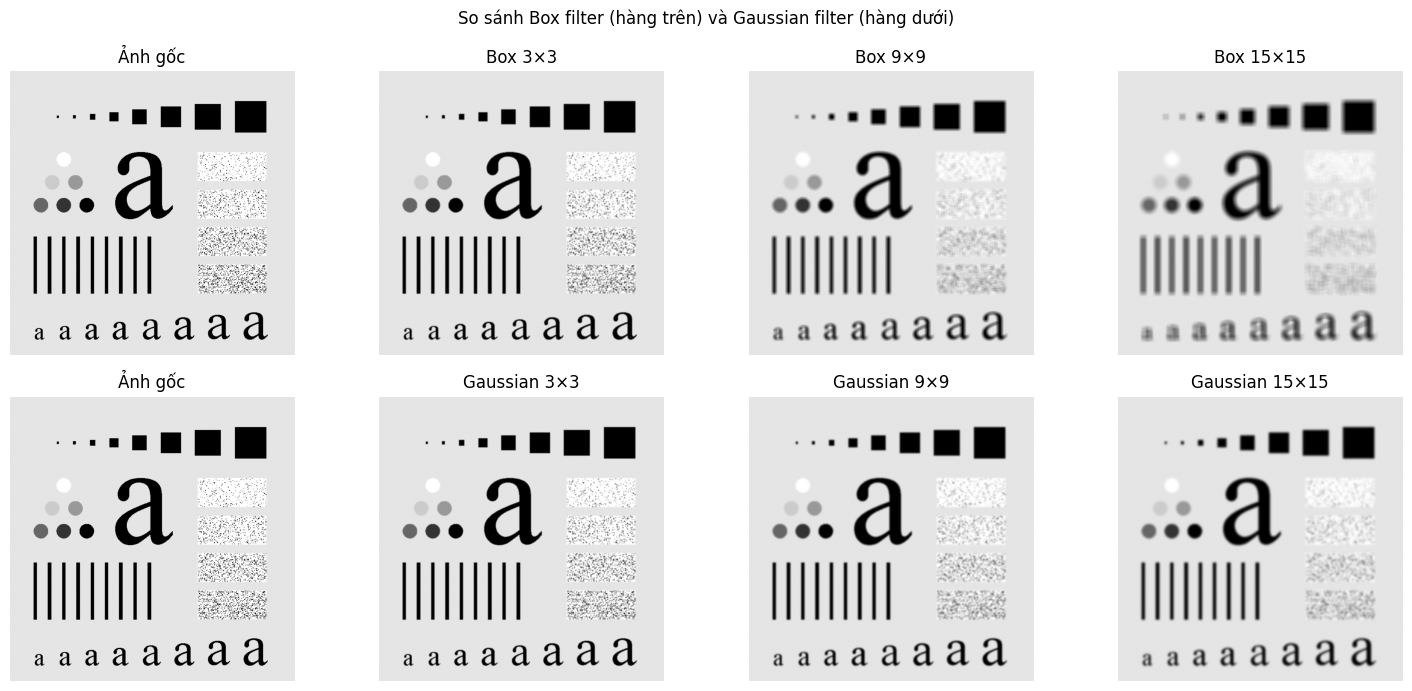

In [2]:
## Ví dụ 2: Bộ lọc tuyến tính làm mịn — Box filter vs Gaussian filter
# Ảnh test pattern kinh điển (Gonzalez & Woods, Fig 3.35/0237).
# Quan sát: kích thước kernel càng lớn -> ảnh càng mờ; Gaussian giữ biên "mềm" hơn box.

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("Fig0237(a)(characters test pattern)_POST.tif").convert("L"))

ksizes = [3, 9, 15]
fig, axes = plt.subplots(2, len(ksizes) + 1, figsize=(15, 7))

axes[0, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Ảnh gốc"); axes[0, 0].axis("off")
axes[1, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Ảnh gốc"); axes[1, 0].axis("off")

for j, k in enumerate(ksizes, start=1):
    box = cv2.blur(img, (k, k))                       # box (mean) filter
    gauss = cv2.GaussianBlur(img, (k, k), 0)          # Gaussian, sigma tự tính từ k
    axes[0, j].imshow(box, cmap="gray", vmin=0, vmax=255)
    axes[0, j].set_title(f"Box {k}×{k}"); axes[0, j].axis("off")
    axes[1, j].imshow(gauss, cmap="gray", vmin=0, vmax=255)
    axes[1, j].set_title(f"Gaussian {k}×{k}"); axes[1, j].axis("off")

plt.suptitle("So sánh Box filter (hàng trên) và Gaussian filter (hàng dưới)")
plt.tight_layout()
plt.show()


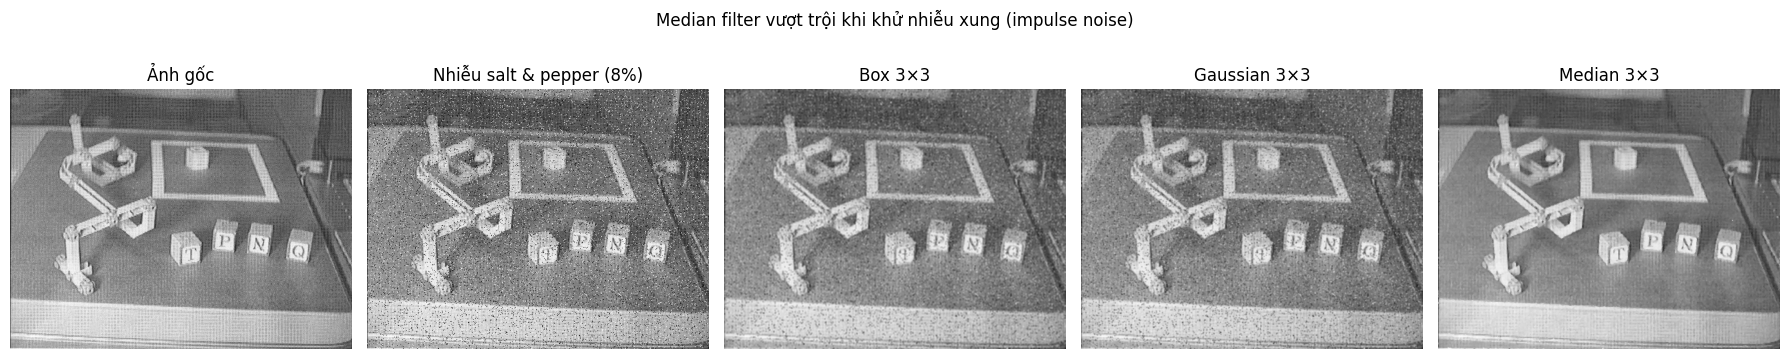

In [3]:
## Ví dụ 3: Khử nhiễu muối–tiêu — Median filter vs bộ lọc tuyến tính
# Thêm nhiễu salt & pepper vào ảnh, so sánh: box, Gaussian, median.
# Quan sát: median khử nhiễu xung rất tốt và giữ biên; lọc tuyến tính làm nhiễu "loang" ra.

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

def add_salt_pepper(img, prob=0.05, seed=0):
    """Thêm nhiễu muối-tiêu: mỗi pixel có xác suất prob/2 thành 0 và prob/2 thành 255."""
    rng = np.random.default_rng(seed)
    noisy = img.copy()
    r = rng.random(img.shape)
    noisy[r < prob / 2] = 0                # pepper
    noisy[r > 1 - prob / 2] = 255          # salt
    return noisy

img = np.asarray(Image.open("image2.png").convert("L"))
noisy = add_salt_pepper(img, prob=0.08)

box = cv2.blur(noisy, (3, 3))
gauss = cv2.GaussianBlur(noisy, (3, 3), 0)
median = cv2.medianBlur(noisy, 3)

titles = ["Ảnh gốc", "Nhiễu salt & pepper (8%)", "Box 3×3", "Gaussian 3×3", "Median 3×3"]
images = [img, noisy, box, gauss, median]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(t); ax.axis("off")
plt.suptitle("Median filter vượt trội khi khử nhiễu xung (impulse noise)")
plt.tight_layout()
plt.show()


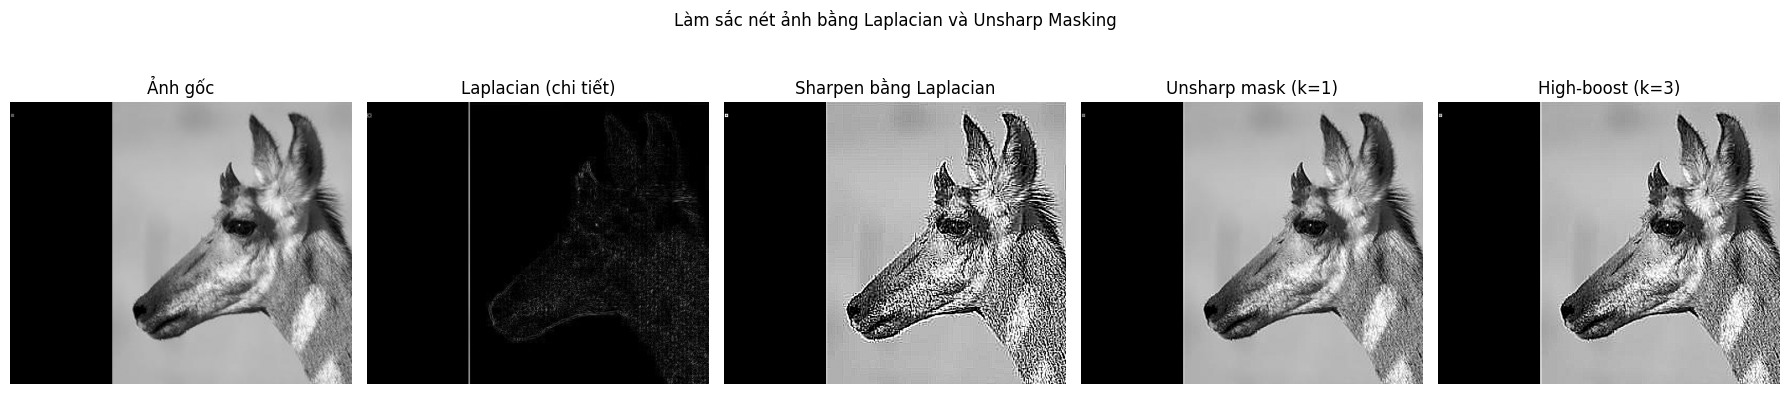

In [4]:
## Ví dụ 4: Làm sắc nét — Laplacian và Unsharp Masking
# - Laplacian (đạo hàm bậc 2) phát hiện chi tiết/biên; cộng ngược vào ảnh để làm nét.
# - Unsharp masking: mask = ảnh gốc - ảnh làm mịn; ảnh nét = gốc + k * mask.

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("image3.png").convert("L")).astype(np.float32)

# --- Laplacian sharpening ---
lap = cv2.Laplacian(img, cv2.CV_32F, ksize=3)
sharp_lap = np.clip(img - lap, 0, 255)          # trừ vì kernel Laplacian tâm dương

# --- Unsharp masking / High-boost ---
blur = cv2.GaussianBlur(img, (5, 5), 0)
mask = img - blur
sharp_unsharp = np.clip(img + 1.0 * mask, 0, 255)   # k = 1: unsharp masking
sharp_highboost = np.clip(img + 3.0 * mask, 0, 255) # k > 1: high-boost filtering

titles = ["Ảnh gốc", "Laplacian (chi tiết)", "Sharpen bằng Laplacian",
          "Unsharp mask (k=1)", "High-boost (k=3)"]
images = [img, np.abs(lap), sharp_lap, sharp_unsharp, sharp_highboost]

fig, axes = plt.subplots(1, 5, figsize=(18, 4.5))
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap="gray")
    ax.set_title(t); ax.axis("off")
plt.suptitle("Làm sắc nét ảnh bằng Laplacian và Unsharp Masking")
plt.tight_layout()
plt.show()


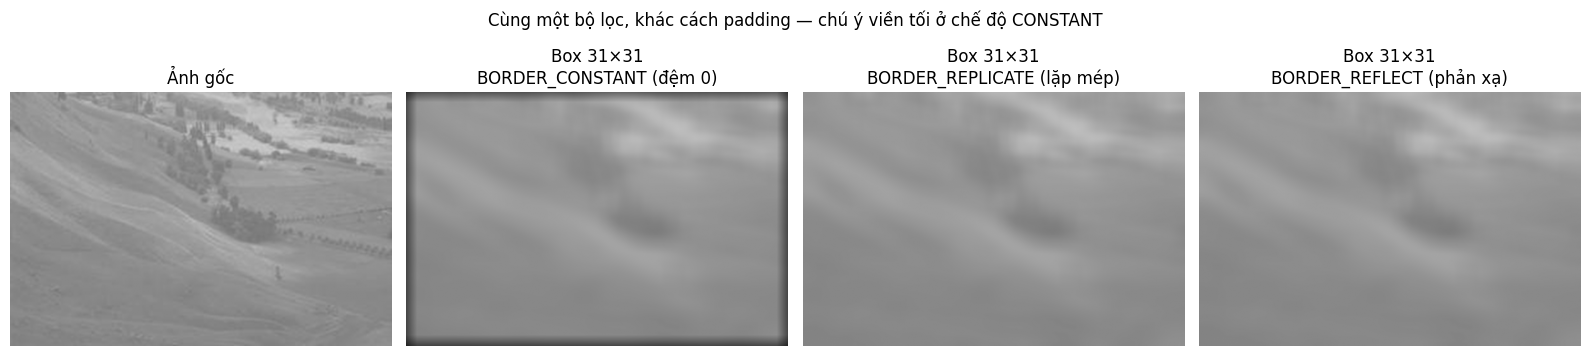

In [5]:
## Ví dụ 5: Ảnh hưởng của Padding (border handling)
# Khi kernel trượt ra mép ảnh cần "đệm" giá trị bên ngoài.
# So sánh các chế độ: CONSTANT (0), REPLICATE, REFLECT — quan sát vùng sát mép ảnh.

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("image1.png").convert("L"))
k = 31  # kernel lớn để thấy rõ hiệu ứng ở mép

modes = [("BORDER_CONSTANT (đệm 0)", cv2.BORDER_CONSTANT),
         ("BORDER_REPLICATE (lặp mép)", cv2.BORDER_REPLICATE),
         ("BORDER_REFLECT (phản xạ)", cv2.BORDER_REFLECT)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Ảnh gốc"); axes[0].axis("off")

for ax, (name, mode) in zip(axes[1:], modes):
    out = cv2.blur(img, (k, k), borderType=mode)
    ax.imshow(out, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Box {k}×{k}\n{name}"); ax.axis("off")

plt.suptitle("Cùng một bộ lọc, khác cách padding — chú ý viền tối ở chế độ CONSTANT")
plt.tight_layout()
plt.show()


## 📝 Exercises (en)
1. Using `bt1_image1.png` and its mask `bt1_image1_mask.png`, smooth the image with a large box filter, then threshold the result to isolate the brightest region. Compare with the given mask.
2. `bt2_original.gif`, `bt2_Gaussian.gif`, `bt2_Salt_and_Pepper.gif` contain an original image and two noisy versions. Choose the most suitable filter (box / Gaussian / median) for each noise type and justify your choice by comparing results.
3. Sharpen `bt3_original_1.png` and `bt3_original_2.png` using both Laplacian and unsharp masking. Experiment with different values of `k` in high-boost filtering.
4. Implement 2-D convolution from scratch with NumPy (no `cv2.filter2D`) supporting zero and replicate padding. Verify your result against OpenCV.
5. (Optional) Measure and compare the runtime of your NumPy implementation vs OpenCV for different kernel sizes.

## 📝 Bài tập (vi)
1. Dùng `bt1_image1.png` và mask `bt1_image1_mask.png`: làm mịn ảnh bằng box filter kích thước lớn, sau đó phân ngưỡng để tách vùng sáng nhất. So sánh với mask cho trước.
2. `bt2_original.gif`, `bt2_Gaussian.gif`, `bt2_Salt_and_Pepper.gif` gồm ảnh gốc và hai ảnh nhiễu. Chọn bộ lọc phù hợp nhất (box / Gaussian / median) cho từng loại nhiễu và giải thích lựa chọn bằng cách so sánh kết quả.
3. Làm sắc nét `bt3_original_1.png` và `bt3_original_2.png` bằng cả Laplacian và unsharp masking. Thử các giá trị `k` khác nhau trong high-boost filtering.
4. Tự cài đặt tích chập 2-D bằng NumPy (không dùng `cv2.filter2D`), hỗ trợ padding zero và replicate. Đối chiếu kết quả với OpenCV.
5. (Tuỳ chọn) Đo và so sánh thời gian chạy giữa bản NumPy tự cài đặt và OpenCV với các kích thước kernel khác nhau.